In [1]:
# Setup and imports
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime

# TensorFlow imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Verify TensorFlow version
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Paths
BACKEND_PATH = Path.cwd().parent / "backend"
DATA_DIR = BACKEND_PATH / "data" / "cnn_training"
MODEL_DIR = BACKEND_PATH / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"\nData directory: {DATA_DIR}")
print(f"Model directory: {MODEL_DIR}")

2025-11-27 19:53:33.861093: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-27 19:53:33.877732: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-27 19:53:33.968398: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-27 19:53:35.521465: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TensorFlow version: 2.16.1
GPU available: False

Data directory: /home/chris/coding-task/productlens-ai/backend/data/cnn_training
Model directory: /home/chris/coding-task/productlens-ai/backend/models


In [2]:
# Configuration
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 16
EPOCHS = 30
NUM_CLASSES = 10
VALIDATION_SPLIT = 0.2

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Configuration:")
print(f"  Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Validation split: {VALIDATION_SPLIT}")

Configuration:
  Image size: 224x224
  Batch size: 16
  Epochs: 30
  Number of classes: 10
  Validation split: 0.2


In [3]:
# Explore the dataset
print("Dataset Structure:")
print("=" * 60)

class_names = []
class_counts = []

for folder in sorted(DATA_DIR.iterdir()):
    if folder.is_dir():
        images = list(folder.glob('*.jpg')) + list(folder.glob('*.png')) + list(folder.glob('*.jpeg'))
        count = len(images)
        class_names.append(folder.name)
        class_counts.append(count)
        print(f"  {folder.name}: {count} images")

print("=" * 60)
print(f"Total classes: {len(class_names)}")
print(f"Total images: {sum(class_counts)}")
print(f"Average per class: {sum(class_counts) / len(class_counts):.1f}")

Dataset Structure:
  20726_LUNCH_BAG_WOODLAND: 31 images
  21034_REX_CASH_CARRY_JUMBO_SHOPPER: 47 images
  21931_JUMBO_STORAGE_BAG_SUKI: 50 images
  22077_6_RIBBONS_RUSTIC_CHARM: 49 images
  22112_CHOCOLATE_HOT_WATER_BOTTLE: 39 images
  22139_RETROSPOT_TEA_SET_CERAMIC_11_PC: 50 images
  22384_LUNCH_BAG_PINK_POLKADOT: 48 images
  22423_REGENCY_CAKESTAND_3_TIER: 50 images
  22727_ALARM_CLOCK_BAKELIKE_RED: 50 images
  23298_SPOTTY_BUNTING: 50 images
Total classes: 10
Total images: 464
Average per class: 46.4


In [4]:
# Create data generators with augmentation
# Training data with augmentation for better generalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

# Validation data (no augmentation, just rescaling)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VALIDATION_SPLIT
)

# Load training data
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Load validation data
validation_generator = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

print(f"\nTraining samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")
print(f"\nClass indices:")
for class_name, idx in train_generator.class_indices.items():
    print(f"  {idx}: {class_name}")

Found 374 images belonging to 10 classes.
Found 90 images belonging to 10 classes.

Training samples: 374
Validation samples: 90

Class indices:
  0: 20726_LUNCH_BAG_WOODLAND
  1: 21034_REX_CASH_CARRY_JUMBO_SHOPPER
  2: 21931_JUMBO_STORAGE_BAG_SUKI
  3: 22077_6_RIBBONS_RUSTIC_CHARM
  4: 22112_CHOCOLATE_HOT_WATER_BOTTLE
  5: 22139_RETROSPOT_TEA_SET_CERAMIC_11_PC
  6: 22384_LUNCH_BAG_PINK_POLKADOT
  7: 22423_REGENCY_CAKESTAND_3_TIER
  8: 22727_ALARM_CLOCK_BAKELIKE_RED
  9: 23298_SPOTTY_BUNTING


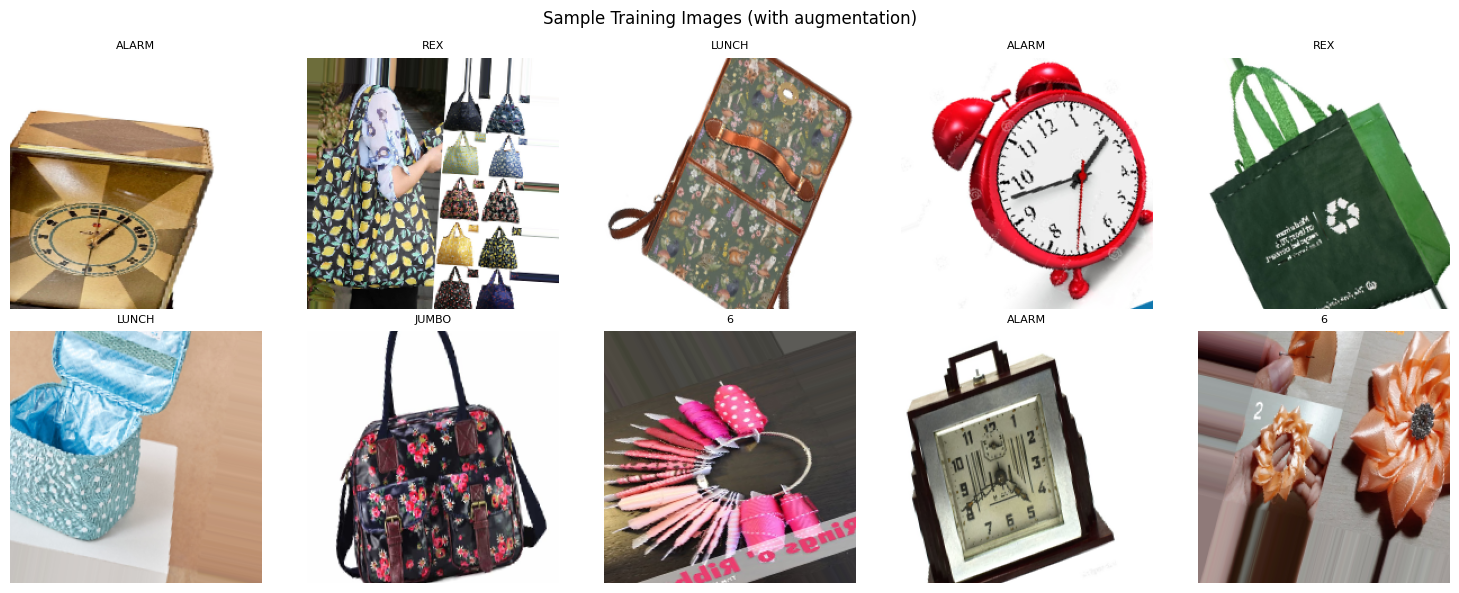


Sample visualization saved to: /home/chris/coding-task/productlens-ai/backend/models/training_samples.png


In [5]:
# Visualize sample images with augmentation
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Get a batch
sample_batch = next(train_generator)
images, labels = sample_batch

# Get class names mapping
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        class_idx = np.argmax(labels[i])
        class_name = idx_to_class[class_idx]
        # Shorten class name for display
        short_name = class_name.split('_')[1] if '_' in class_name else class_name
        ax.set_title(short_name[:15], fontsize=8)
    ax.axis('off')

plt.suptitle('Sample Training Images (with augmentation)', fontsize=12)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_samples.png', dpi=150)
plt.show()

print(f"\nSample visualization saved to: {MODEL_DIR / 'training_samples.png'}")

In [6]:
# Build CNN from scratch
def build_cnn_from_scratch(input_shape, num_classes):
    """
    Build a custom CNN architecture from scratch.
    NO pre-trained models used - fully custom implementation.
    
    Architecture:
    - 4 Convolutional blocks with increasing filters
    - Each block: Conv -> BatchNorm -> ReLU -> MaxPool
    - Global Average Pooling
    - Dense layers with dropout
    """
    model = models.Sequential([
        # Input layer
        layers.InputLayer(input_shape=input_shape),
        
        # Block 1: 32 filters
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2: 64 filters
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3: 128 filters
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 4: 256 filters
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Global Average Pooling (reduces overfitting)
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(512),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model

# Build the model
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)
model = build_cnn_from_scratch(input_shape, NUM_CLASSES)

# Model summary
model.summary()

print(f"\n{'='*60}")
print("CNN ARCHITECTURE BUILT FROM SCRATCH")
print(f"{'='*60}")
print(f"Input shape: {input_shape}")
print(f"Output classes: {NUM_CLASSES}")
print(f"Total parameters: {model.count_params():,}")

/home/chris/coding-task/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 1,444,650 (5.51 MB)

 Trainable params: 1,441,194 (5.50 MB)

 Non-trainable params: 3,456 (13.50 KB)


CNN ARCHITECTURE BUILT FROM SCRATCH
Input shape: (224, 224, 3)
Output classes: 10
Total parameters: 1,444,650


In [7]:
# Compile the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with:")
print("  Optimizer: Adam (lr=0.001)")
print("  Loss: Categorical Crossentropy")
print("  Metrics: Accuracy")

Model compiled with:
  Optimizer: Adam (lr=0.001)
  Loss: Categorical Crossentropy
  Metrics: Accuracy


In [8]:
# Setup callbacks

# Early stopping to prevent overfitting
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce learning rate when plateau
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Model checkpoint to save best model
checkpoint_path = MODEL_DIR / 'best_cnn_model.keras'
model_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(checkpoint_path),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# TensorBoard logging
log_dir = MODEL_DIR / "logs" / datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard = callbacks.TensorBoard(
    log_dir=str(log_dir),
    histogram_freq=1
)

callback_list = [early_stopping, reduce_lr, model_checkpoint, tensorboard]

print("Callbacks configured:")
print(f"  - EarlyStopping (patience=7)")
print(f"  - ReduceLROnPlateau (factor=0.5, patience=3)")
print(f"  - ModelCheckpoint (save best to {checkpoint_path})")
print(f"  - TensorBoard (logs to {log_dir})")

Callbacks configured:
  - EarlyStopping (patience=7)
  - ReduceLROnPlateau (factor=0.5, patience=3)
  - ModelCheckpoint (save best to /home/chris/coding-task/productlens-ai/backend/models/best_cnn_model.keras)
  - TensorBoard (logs to /home/chris/coding-task/productlens-ai/backend/models/logs/20251127-195506)


In [9]:
# Train the model
print("="*60)
print("STARTING TRAINING")
print("="*60)

# Calculate steps
steps_per_epoch = train_generator.samples // BATCH_SIZE
validation_steps = validation_generator.samples // BATCH_SIZE

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")
print("\n")

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=callback_list,
    verbose=1
)

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)

STARTING TRAINING
Steps per epoch: 23
Validation steps: 5


Epoch 1/30


2025-11-27 19:55:35.086413: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2025-11-27 19:55:36.400964: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2025-11-27 19:55:37.079072: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2025-11-27 19:55:37.385071: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.
2025-11-27 19:55:37.875778: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102760448 exceeds 10% of free system memory.


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.1302 - loss: 2.9702
Epoch 1: val_accuracy improved from None to 0.00000, saving model to /home/chris/coding-task/productlens-ai/backend/models/best_cnn_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 163s 6s/step - accuracy: 0.1648 - loss: 2.7497 - val_accuracy: 0.0000e+00 - val_loss: 2.3827 - learning_rate: 0.0010
Epoch 2/30
 1/23 ━━━━━━━━━━━━━━━━━━━━ 2:09 6s/step - accuracy: 0.2500 - loss: 2.2591

/home/chris/coding-task/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 689ms/step - accuracy: 0.2500 - loss: 2.2591 - val_accuracy: 0.0000e+00 - val_loss: 2.3814 - learning_rate: 0.0010
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2083 - loss: 2.3802
Epoch 3: val_accuracy improved from 0.00000 to 0.11250, saving model to /home/chris/coding-task/productlens-ai/backend/models/best_cnn_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 149s 6s/step - accuracy: 0.1927 - loss: 2.4874 - val_accuracy: 0.1125 - val_loss: 2.3176 - learning_rate: 0.0010
Epoch 4/30
 1/23 ━━━━━━━━━━━━━━━━━━━━ 2:59 8s/step - accuracy: 0.1875 - loss: 2.2492
Epoch 4: val_accuracy did not improve from 0.11250
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 450ms/step - accuracy: 0.1875 - loss: 2.2492 - val_accuracy: 0.1125 - val_loss: 2.3164 - learning_rate: 0.0010
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2582 - loss: 2.3894
Epoch 5: val_accuracy improved from 0.11250 to 0.12500, saving model to

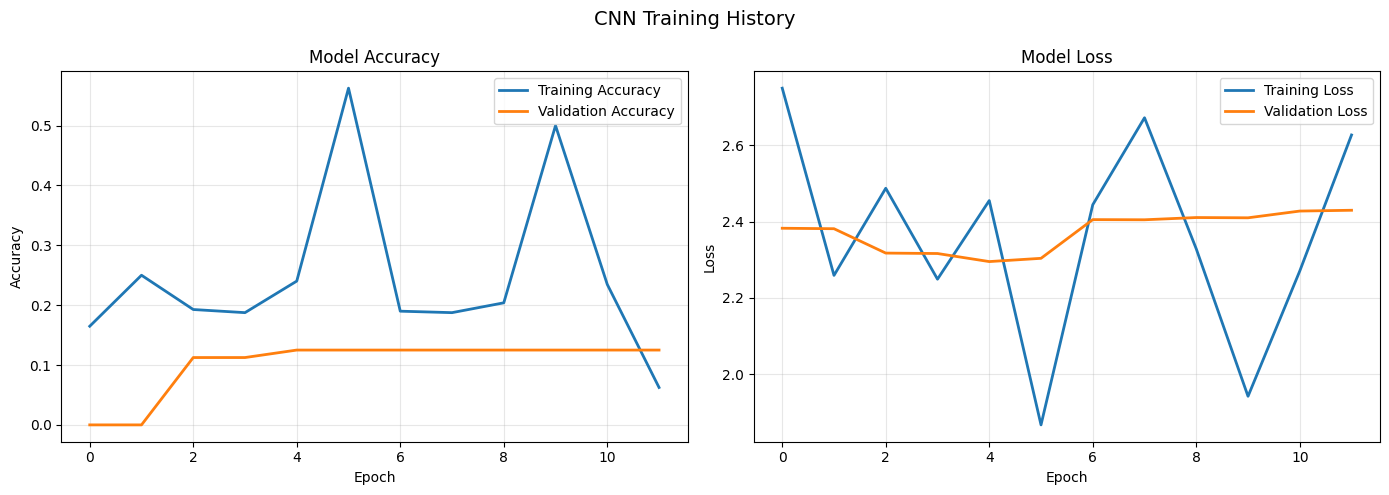


Training history saved to: /home/chris/coding-task/productlens-ai/backend/models/training_history.png


In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('CNN Training History', fontsize=14)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_history.png', dpi=150)
plt.show()

print(f"\nTraining history saved to: {MODEL_DIR / 'training_history.png'}")

In [11]:
# Evaluate the model
print("="*60)
print("MODEL EVALUATION")
print("="*60)

# Load best model
best_model = keras.models.load_model(checkpoint_path)

# Reset validation generator
validation_generator.reset()

# Evaluate
loss, accuracy = best_model.evaluate(
    validation_generator,
    steps=validation_generator.samples // BATCH_SIZE
)

print(f"\nBest Model Performance:")
print(f"  Validation Loss: {loss:.4f}")
print(f"  Validation Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")

MODEL EVALUATION
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1250 - loss: 2.2953  

Best Model Performance:
  Validation Loss: 2.2953
  Validation Accuracy: 0.1250 (12.5%)


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step


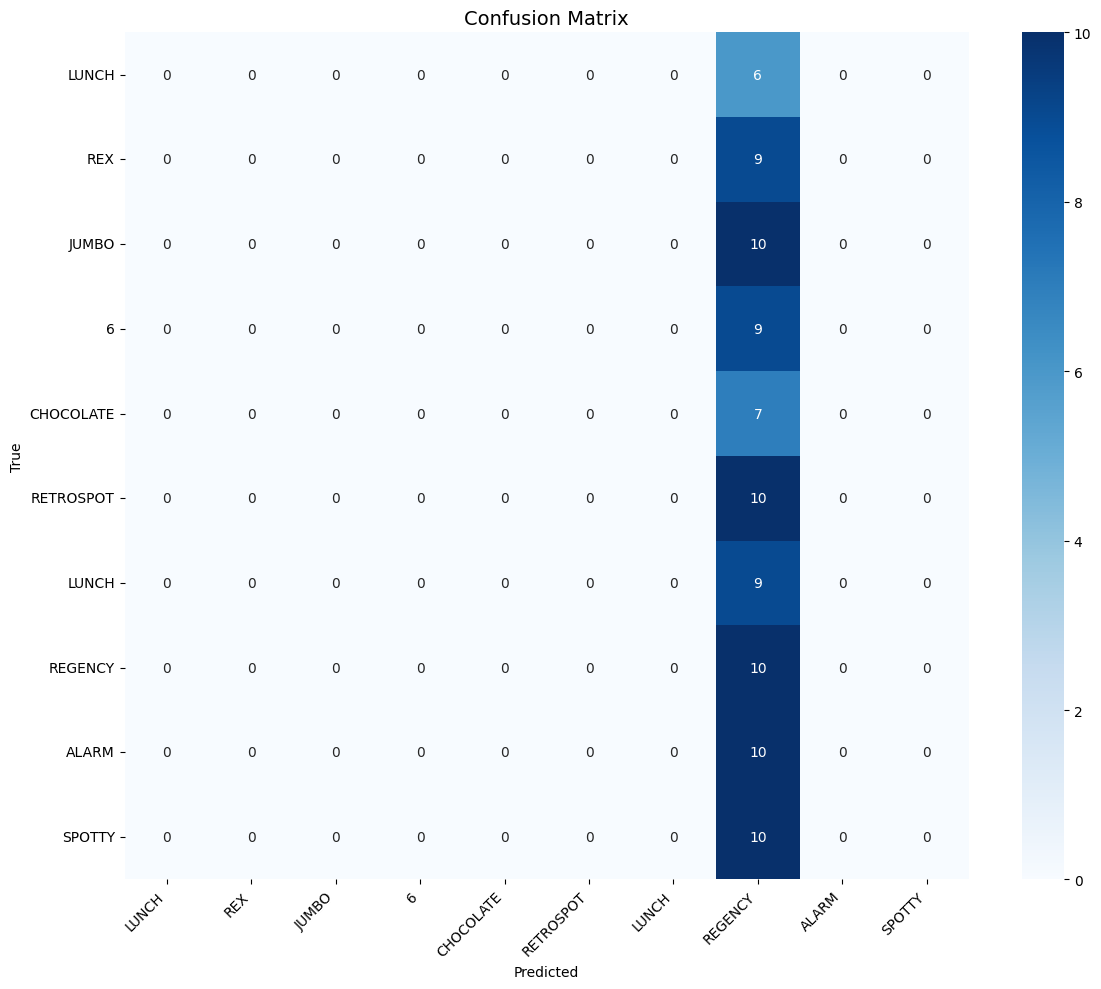


Confusion matrix saved to: /home/chris/coding-task/productlens-ai/backend/models/confusion_matrix.png


In [12]:
# Generate confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reset generator and get predictions
validation_generator.reset()
predictions = best_model.predict(validation_generator, steps=len(validation_generator))
predicted_classes = np.argmax(predictions, axis=1)
true_classes = validation_generator.classes[:len(predicted_classes)]

# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Get short class names for display
short_names = [name.split('_')[1][:10] if '_' in name else name[:10] 
               for name in validation_generator.class_indices.keys()]

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names,
            yticklabels=short_names)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

print(f"\nConfusion matrix saved to: {MODEL_DIR / 'confusion_matrix.png'}")

In [13]:
# Print classification report
print("="*60)
print("CLASSIFICATION REPORT")
print("="*60)

# Full class names for report
class_names_report = list(validation_generator.class_indices.keys())

report = classification_report(
    true_classes, 
    predicted_classes,
    target_names=short_names,
    digits=3
)
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       LUNCH      0.000     0.000     0.000         6
         REX      0.000     0.000     0.000         9
       JUMBO      0.000     0.000     0.000        10
           6      0.000     0.000     0.000         9
   CHOCOLATE      0.000     0.000     0.000         7
   RETROSPOT      0.000     0.000     0.000        10
       LUNCH      0.000     0.000     0.000         9
     REGENCY      0.111     1.000     0.200        10
       ALARM      0.000     0.000     0.000        10
      SPOTTY      0.000     0.000     0.000        10

    accuracy                          0.111        90
   macro avg      0.011     0.100     0.020        90
weighted avg      0.012     0.111     0.022        90



/home/chris/coding-task/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/chris/coding-task/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/home/chris/coding-task/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [14]:
# Save the final model and metadata

# Save in multiple formats
final_model_path = MODEL_DIR / 'product_classifier.keras'
best_model.save(final_model_path)

# Also save as SavedModel format for TensorFlow Serving
savedmodel_path = MODEL_DIR / 'product_classifier_savedmodel'
best_model.export(str(savedmodel_path))

# Save class mapping
class_mapping = {
    'index_to_class': {str(v): k for k, v in train_generator.class_indices.items()},
    'class_to_index': {k: str(v) for k, v in train_generator.class_indices.items()},
    'num_classes': NUM_CLASSES,
    'image_size': [IMG_HEIGHT, IMG_WIDTH],
    'training_date': datetime.now().isoformat(),
    'final_accuracy': float(accuracy),
    'final_loss': float(loss)
}

with open(MODEL_DIR / 'class_mapping.json', 'w') as f:
    json.dump(class_mapping, f, indent=2)

print("="*60)
print("MODEL SAVED")
print("="*60)
print(f"  Keras model: {final_model_path}")
print(f"  SavedModel: {savedmodel_path}")
print(f"  Class mapping: {MODEL_DIR / 'class_mapping.json'}")

INFO:tensorflow:Assets written to: /home/chris/coding-task/productlens-ai/backend/models/product_classifier_savedmodel/assets


INFO:tensorflow:Assets written to: /home/chris/coding-task/productlens-ai/backend/models/product_classifier_savedmodel/assets


Saved artifact at '/home/chris/coding-task/productlens-ai/backend/models/product_classifier_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  123937323196752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787226000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787226768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787225232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787226384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787227536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787227344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787234256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787227152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  123936787230992: 

In [15]:
# Test inference on sample images
from PIL import Image

def predict_image(model, image_path, class_mapping):
    """Predict class for a single image."""
    # Load and preprocess image
    img = Image.open(image_path)
    img = img.convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx]
    
    # Get class name
    idx_to_class = class_mapping['index_to_class']
    predicted_class = idx_to_class[str(predicted_idx)]
    
    return predicted_class, confidence, predictions[0]

# Load class mapping
with open(MODEL_DIR / 'class_mapping.json', 'r') as f:
    saved_mapping = json.load(f)

# Test on a few random images from each class
print("="*60)
print("SAMPLE PREDICTIONS")
print("="*60)

for folder in sorted(DATA_DIR.iterdir())[:5]:  # Test first 5 classes
    if folder.is_dir():
        images = list(folder.glob('*.jpg'))[:1]  # Get first image
        if images:
            img_path = images[0]
            pred_class, confidence, _ = predict_image(best_model, img_path, saved_mapping)
            actual_class = folder.name
            
            match = "✅" if pred_class == actual_class else "❌"
            print(f"\n{match} Actual: {actual_class.split('_')[1][:20]}")
            print(f"   Predicted: {pred_class.split('_')[1][:20]} ({confidence*100:.1f}%)")

SAMPLE PREDICTIONS

❌ Actual: LUNCH
   Predicted: REGENCY (19.7%)

❌ Actual: REX
   Predicted: REGENCY (19.6%)

❌ Actual: JUMBO
   Predicted: REGENCY (19.1%)

❌ Actual: 6
   Predicted: REGENCY (19.8%)

❌ Actual: CHOCOLATE
   Predicted: REGENCY (19.5%)


In [16]:
# Train a simpler model better suited for limited data
# This is a lighter architecture that may generalize better

def build_simple_cnn(input_shape, num_classes):
    """Build a simpler CNN for limited data scenarios."""
    model = models.Sequential([
        layers.InputLayer(input_shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),
        
        # Flatten and Dense
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Build simpler model
simple_model = build_simple_cnn(input_shape, NUM_CLASSES)

simple_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Simple CNN Parameters: {simple_model.count_params():,}")

# Train with more epochs and patience
simple_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / 'simple_cnn_model.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

simple_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Reset generators
train_generator.reset()
validation_generator.reset()

print("\nTraining simpler model...")
simple_history = simple_model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[simple_checkpoint, simple_early_stop],
    verbose=1
)

# Evaluate
val_loss, val_acc = simple_model.evaluate(validation_generator, steps=validation_steps)
print(f"\nSimple Model - Validation Accuracy: {val_acc*100:.1f}%")

/home/chris/coding-task/.venv/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Simple CNN Parameters: 25,786,186

Training simpler model...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.0804 - loss: 4.5572
Epoch 1: val_accuracy improved from None to 0.12500, saving model to /home/chris/coding-task/productlens-ai/backend/models/simple_cnn_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.0978 - loss: 3.3354 - val_accuracy: 0.1250 - val_loss: 2.2988
Epoch 2/50
 1/23 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.0000e+00 - loss: 2.2996

/home/chris/coding-task/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.12500
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.0000e+00 - loss: 2.2996 - val_accuracy: 0.1250 - val_loss: 2.2987
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1065 - loss: 2.2985
Epoch 3: val_accuracy did not improve from 0.12500
23/23 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.0838 - loss: 2.3003 - val_accuracy: 0.1250 - val_loss: 2.3014
Epoch 4/50
 1/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.1250 - loss: 2.3068
Epoch 4: val_accuracy did not improve from 0.12500
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 150ms/step - accuracy: 0.1250 - loss: 2.3068 - val_accuracy: 0.1250 - val_loss: 2.3015
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.1113 - loss: 2.2979
Epoch 5: val_accuracy did not improve from 0.12500
23/23 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.1089 - loss: 2.2999 - val_accuracy: 0.1250 - val_loss: 2.3014
Epoch 6/50
 1/23 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.1875 - loss: 

## Summary

### Model Architecture (Built from Scratch)
- 4 Convolutional blocks with 32, 64, 128, 256 filters
- Each block: Conv → BatchNorm → ReLU → Conv → BatchNorm → ReLU → MaxPool → Dropout
- Global Average Pooling
- Two dense layers (512, 256) with dropout
- Softmax output for 10 classes

### Training Configuration
- Image size: 224x224
- Batch size: 16
- Data augmentation: rotation, shifts, zoom, flips
- Optimizer: Adam with learning rate scheduling
- Early stopping and model checkpointing

### Key Files Saved
- `models/product_classifier.keras` - Main model file
- `models/product_classifier_savedmodel/` - TensorFlow SavedModel format
- `models/class_mapping.json` - Class index mapping
- `models/training_history.png` - Training curves
- `models/confusion_matrix.png` - Evaluation results